### **Libraries and Datasets**

Way to download required packages using `pip`:

In [8]:
# %pip install -U numpy
# %pip install -U pandas
# %pip install catboost
# %pip install sklearn
# %pip install optuna
# %pip install matplotlib seaborn
# %pip install lightgbm

Import of necessary libraries:

In [9]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, cross_val_score
import optuna
from sklearn.metrics import mean_absolute_error as mae
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

Datasets uploading:

In [10]:
train_data = pd.read_csv('train_contest.csv')
train_data.head()

,premium,name,department,has_test,response_letter_required,area,type,address,response_url,sort_point_distance,...,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url,mean_salary
0,False,Агент по недвижимости,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Невский...",NaN,NaN,...,[],[],False,"<p>Мы ищем людей, которым не достаточно того, ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",Санкт-Петербург,NaN,125000.0
1,False,IT-специалист/ техник,NaN,False,False,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,NaN,...,[],[],False,<ul> </ul> <p><em><strong>Навыки</strong></em>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",Иркутская область,NaN,50000.0
2,False,Старший/ведущий инженер-программист,NaN,False,False,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Ростов-на-Дону', 'street': '60К-9, 1...",NaN,NaN,...,[],[],False,<strong>Обязанности:</strong> <ul> <li>Разрабо...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",Ростовская область,NaN,80000.0
3,False,Эксперт / методист приемной комиссии,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': '1-я Миусская ули...",NaN,NaN,...,[],[],False,<p>Департамент информационных технологий РХТУ ...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",Москва,NaN,120000.0
4,False,Табельщица/табельщик,NaN,False,False,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': 'open', 'name': 'Открытая'}","{'city': None, 'street': None, 'building': Non...",NaN,NaN,...,[],[],False,<p><strong>Обязанности:</strong></p> <ul> <li>...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",Саратовская область,NaN,15000.0


In [11]:
test_data = pd.read_csv('for_prediction.csv')
test_data.head()

,Id,premium,name,department,has_test,response_letter_required,area,type,address,response_url,...,working_days,working_time_intervals,working_time_modes,accept_temporary,description,experience,key_skills,specializations,region,immediate_redirect_url
0,0,False,Помощник маркетолога,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,...,[],[],[],False,<p>В IT-компанию Ищем Интернет-маркетолога (уд...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Контекстная реклама'}, {'name': 'Ин...","[{'id': '3.206', 'name': 'Печатная реклама', '...",Москва,NaN
1,1,False,Менеджер по персоналу,NaN,False,False,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Санкт-Петербург', 'street': 'Новочер...",NaN,...,[],[],[],False,<p>Мы приглашаем на работу соискателей на долж...,"{'id': 'noExperience', 'name': 'Нет опыта'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...","[{'id': '6.254', 'name': 'Рекрутмент', 'profar...",Санкт-Петербург,NaN
2,2,False,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",NaN,False,False,"{'id': '99', 'name': 'Уфа', 'url': 'https://ap...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Уфа', 'street': 'Рубежная улица', 'b...",NaN,...,[],[],[],False,"<strong>Если ты любишь играть, прыгать и бегат...","{'id': 'noExperience', 'name': 'Нет опыта'}",[],"[{'id': '24.378', 'name': 'Тренерский состав',...",Республика Башкортостан,NaN
3,3,False,Программист Delphi,NaN,False,False,"{'id': '4', 'name': 'Новосибирск', 'url': 'htt...","{'id': 'open', 'name': 'Открытая'}",NaN,NaN,...,[],[],[],False,<p>Компания AMS Software - разработчик популяр...,"{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...","[{'id': '1.221', 'name': 'Программирование, Ра...",Новосибирская область,NaN
4,4,False,Ведущий специалист ВКС,NaN,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': 'open', 'name': 'Открытая'}","{'city': 'Москва', 'street': 'Чистопрудный бул...",NaN,...,[],[],[],False,<p><strong>Компания &quot;ТехноКад&quot; - оди...,"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'name': 'Настройка ПК'}, {'name': 'Техническ...","[{'id': '1.172', 'name': 'Начальный уровень, М...",Москва,NaN


Some preparations of datasets before feature engineering:

In [12]:
train_data.columns

Index(['premium', 'name', 'department', 'has_test', 'response_letter_required',
       'area', 'type', 'address', 'response_url', 'sort_point_distance',
       'published_at', 'created_at', 'archived', 'insider_interview', 'url',
       'alternate_url', 'relations', 'employer', 'snippet', 'contacts',
       'schedule', 'working_days', 'working_time_intervals',
       'working_time_modes', 'accept_temporary', 'description', 'experience',
       'key_skills', 'specializations', 'region', 'immediate_redirect_url',
       'mean_salary'],
      dtype='object')

In [ ]:
features = ['name', 'region', 'employer', 'schedule', 'key_skills', 'experience', 'specializations']
X_train = train_data[features]  # start features
y_train = train_data['mean_salary']  # target variable

In [14]:
X_train.head()

,name,region,area,employer,schedule,key_skills,experience,specializations
0,Агент по недвижимости,Санкт-Петербург,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '20.20', 'name': 'Агент', 'profarea_id..."
1,IT-специалист/ техник,Иркутская область,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.172', 'name': 'Начальный уровень, М..."
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.221', 'name': 'Программирование, Ра..."
3,Эксперт / методист приемной комиссии,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '3.150', 'name': 'Менеджмент продукта ..."
4,Табельщица/табельщик,Саратовская область,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '18.142', 'name': 'Машиностроение', 'p..."


In [15]:
X_test = test_data[features]
X_test.head()

,name,region,area,employer,schedule,key_skills,experience,specializations
0,Помощник маркетолога,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '2710310', 'name': 'EKO BIKE', 'url': '...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Контекстная реклама'}, {'name': 'Ин...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '3.206', 'name': 'Печатная реклама', '..."
1,Менеджер по персоналу,Санкт-Петербург,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '52824', 'name': 'Ваш дом, агентство не...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...","{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '6.254', 'name': 'Рекрутмент', 'profar..."
2,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",Республика Башкортостан,"{'id': '99', 'name': 'Уфа', 'url': 'https://ap...","{'id': '230048', 'name': 'Мегаполис', 'url': '...","{'id': 'fullDay', 'name': 'Полный день'}",[],"{'id': 'noExperience', 'name': 'Нет опыта'}","[{'id': '24.378', 'name': 'Тренерский состав',..."
3,Программист Delphi,Новосибирская область,"{'id': '4', 'name': 'Новосибирск', 'url': 'htt...","{'id': '634253', 'name': 'AMS Software', 'url'...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...","{'id': 'between3And6', 'name': 'От 3 до 6 лет'}","[{'id': '1.221', 'name': 'Программирование, Ра..."
4,Ведущий специалист ВКС,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '36889', 'name': 'Технокад', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Настройка ПК'}, {'name': 'Техническ...","{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.172', 'name': 'Начальный уровень, М..."


### **EDA**

In [16]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30072 entries, 0 to 30071
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             30072 non-null  object
 1   region           30072 non-null  object
 2   area             30072 non-null  object
 3   employer         30072 non-null  object
 4   schedule         30072 non-null  object
 5   key_skills       30072 non-null  object
 6   experience       30072 non-null  object
 7   specializations  30072 non-null  object
dtypes: object(8)
memory usage: 1.8+ MB


In [17]:
X_train.describe()

,name,region,area,employer,schedule,key_skills,experience,specializations
count,30072,30072,30072,30072,30072,30072,30072,30072
unique,13521,82,784,13146,5,20884,4,633
top,Системный администратор,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '1740', 'name': 'Яндекс', 'url': 'https...","{'id': 'fullDay', 'name': 'Полный день'}",[],"{'id': 'between1And3', 'name': 'От 1 года до 3...","[{'id': '1.221', 'name': 'Программирование, Ра..."
freq,926,6236,6236,1193,22711,5206,14758,5669


In [18]:
y_train.describe()

count    3.007200e+04
mean     9.772825e+04
std      1.046010e+05
min      2.000000e+01
25%      4.250000e+04
50%      7.000000e+04
75%      1.200000e+05
max      2.750000e+06
Name: mean_salary, dtype: float64

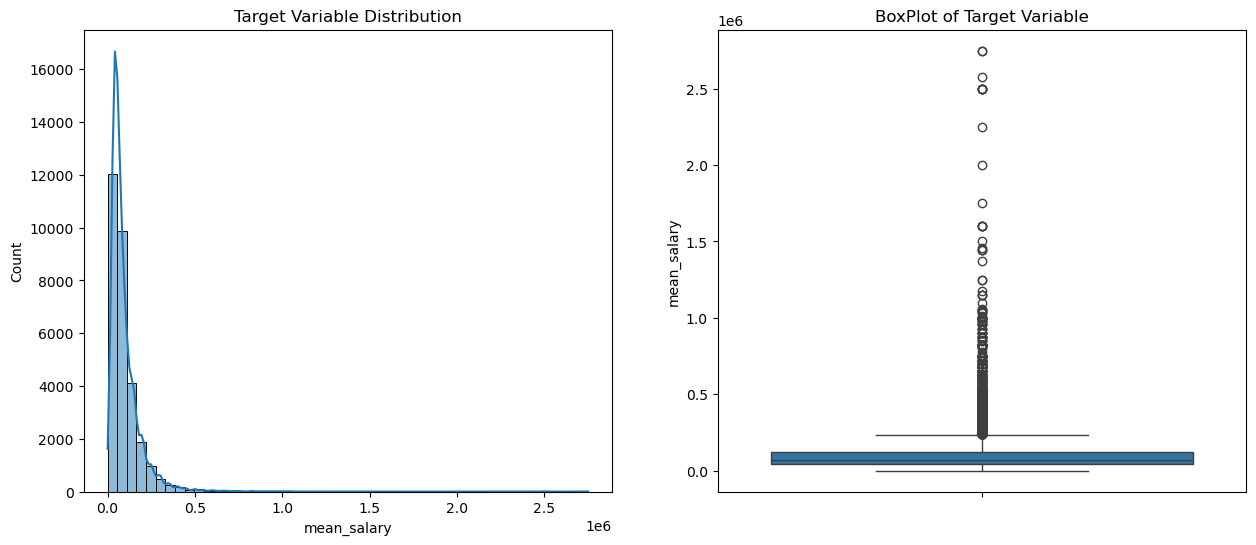

In [19]:
plt.figure(figsize=(15, 6))

ax1 = plt.subplot(1, 2, 1)
sns.histplot(y_train, bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(1, 2, 2)
sns.boxplot(y_train)
plt.title('BoxPlot of Target Variable')

plt.show()

In [20]:
y_train = y_train.to_frame()

In [21]:
y_train['log_mean_salary'] = np.log1p(y_train['mean_salary'])

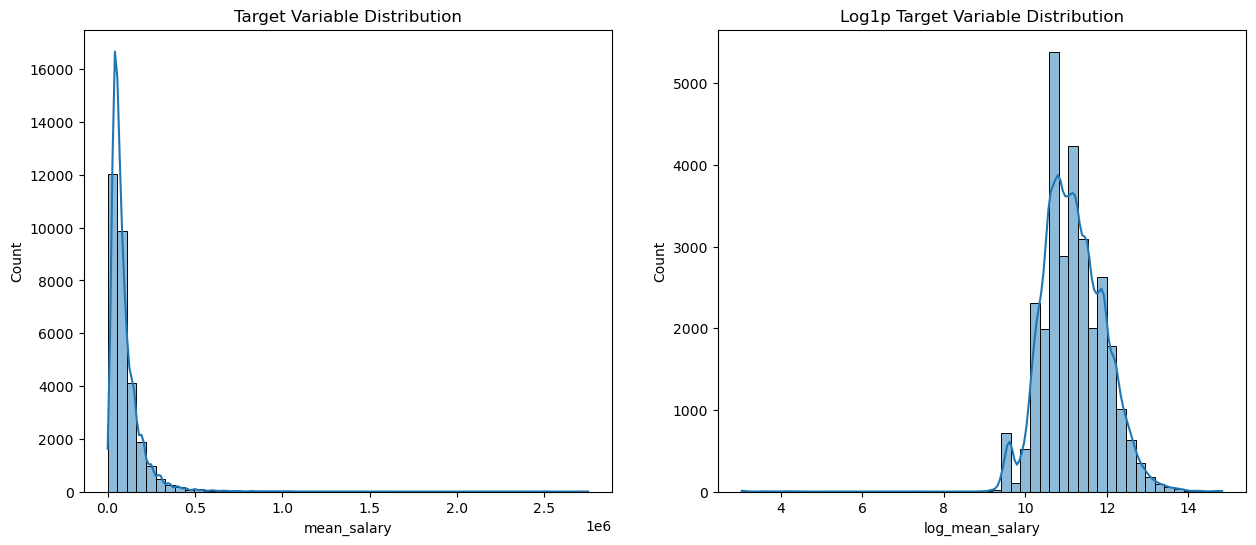

In [22]:
plt.figure(figsize=(15, 6))

ax1 = plt.subplot(1, 2, 1)
sns.histplot(y_train['mean_salary'], bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(1, 2, 2)
sns.histplot(y_train['log_mean_salary'], bins=50, kde=True)
plt.title('Log1p Target Variable Distribution')

plt.show()

In [23]:
scaler = RobustScaler()
y_train['log_mean_salary_scaled'] = scaler.fit_transform(y_train[['log_mean_salary']])

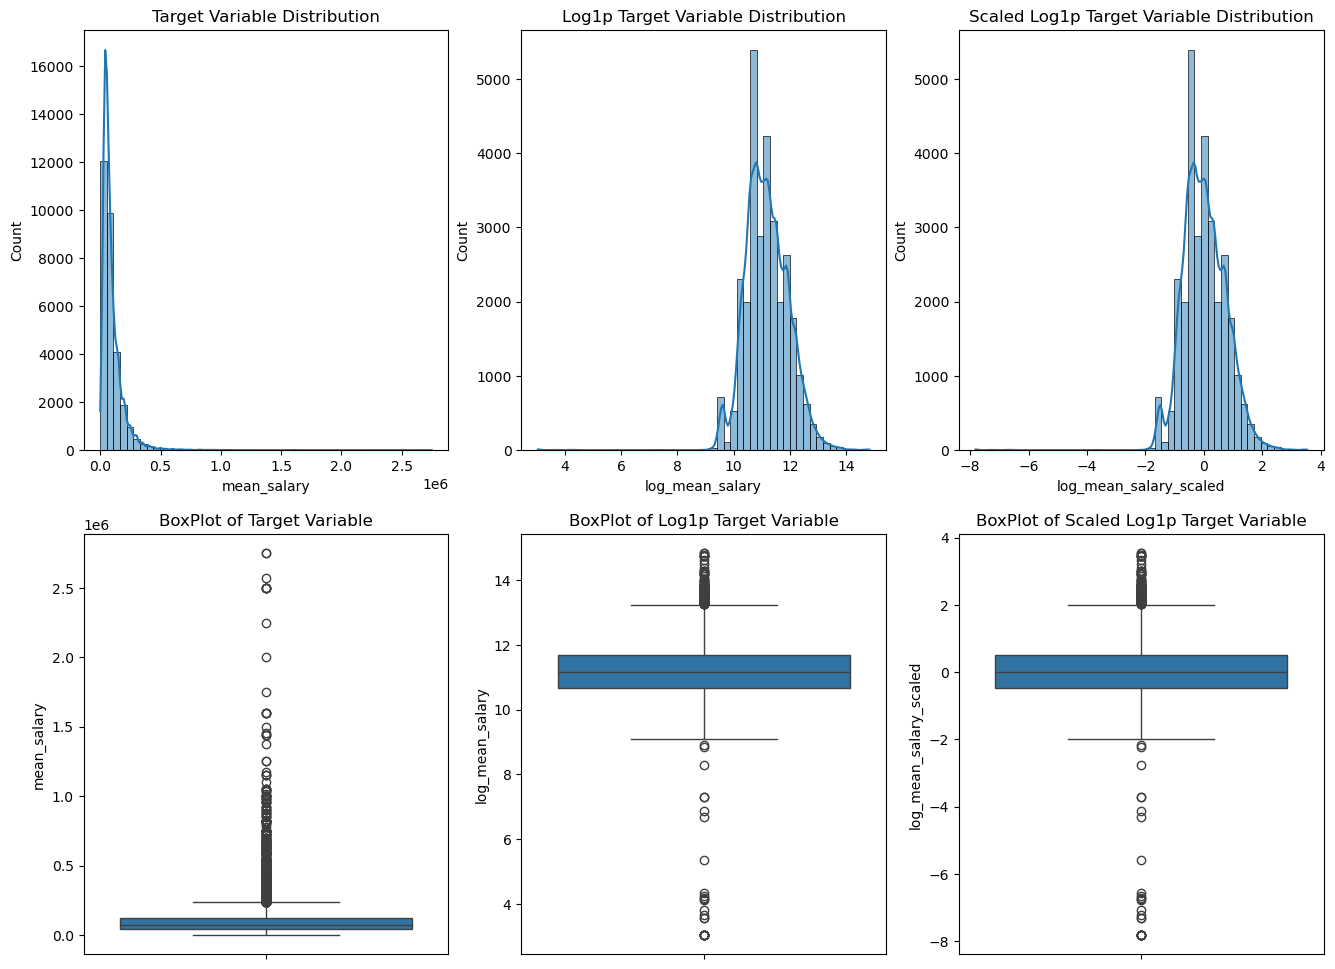

In [24]:
plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 3, 1)
sns.histplot(y_train['mean_salary'], bins=50, kde=True)
plt.title('Target Variable Distribution')

ax2 = plt.subplot(2, 3, 2)
sns.histplot(y_train['log_mean_salary'], bins=50, kde=True)
plt.title('Log1p Target Variable Distribution')

ax5 = plt.subplot(2, 3, 3)
sns.histplot(y_train['log_mean_salary_scaled'], bins=50, kde=True)
plt.title('Scaled Log1p Target Variable Distribution')

ax1 = plt.subplot(2, 3, 4)
sns.boxplot(y_train['mean_salary'])
plt.title('BoxPlot of Target Variable')

ax2 = plt.subplot(2, 3, 5)
sns.boxplot(y_train['log_mean_salary'])
plt.title('BoxPlot of Log1p Target Variable')

ax5 = plt.subplot(2, 3, 6)
sns.boxplot(y_train['log_mean_salary_scaled'])
plt.title('BoxPlot of Scaled Log1p Target Variable')

plt.show()

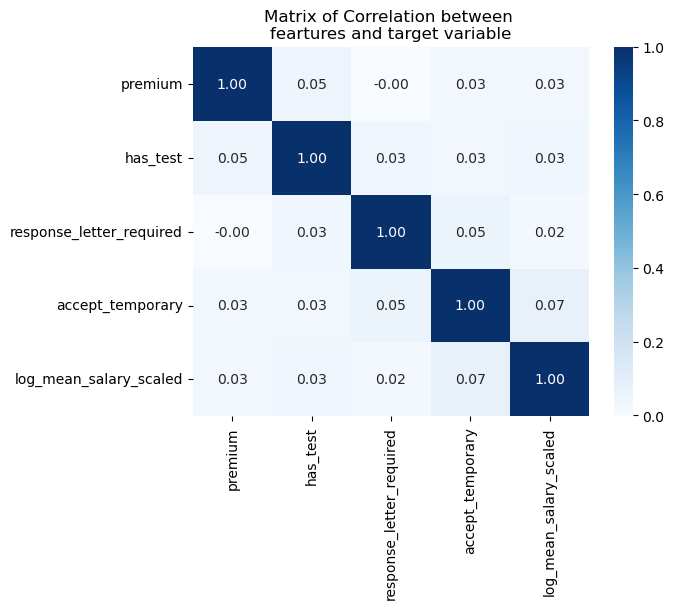

In [25]:
features_corr = pd.concat([train_data[['premium', 'has_test', 'response_letter_required', 'accept_temporary', ]], y_train['log_mean_salary_scaled']], axis=1)
correlation = features_corr.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matrix of Correlation between \nfeartures and target variable')
plt.show()

### **Feature Engineering**

Some ideas and functional realization of feature engineering:

In [26]:
import ast

def str_to_dict(s):
    return ast.literal_eval(s)

In [27]:
len_train, len_test = X_train.shape[0], X_test.shape[0]
print(f'Num of rows in train: {len_train} \nNum of rows in test: {len_test}')

Num of rows in train: 30072 
Num of rows in test: 7518


In [28]:
for df in [X_train, X_test]:
    df['experience_ages'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['experience_ages'][i] = str_to_dict(df['experience'][i])['id']

It is decided to use `OrdinalEncoder` for better interpretation of the *experience* feature:

In [29]:
exp_categories = ['noExperience', 'between1And3', 'between3And6', 'moreThan6']
ord_encoder = OrdinalEncoder(categories=[exp_categories])
for df in [X_train, X_test]:
    df['experience_encoded'] = ord_encoder.fit_transform(df[['experience_ages']])
    df.drop(['experience', 'experience_ages'], axis=1, inplace=True)

In [30]:
X_train.head()

,name,region,area,employer,schedule,key_skills,specializations,experience_encoded
0,Агент по недвижимости,Санкт-Петербург,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...","[{'id': '20.20', 'name': 'Агент', 'profarea_id...",0.0
1,IT-специалист/ техник,Иркутская область,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],"[{'id': '1.172', 'name': 'Начальный уровень, М...",1.0
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...","[{'id': '1.221', 'name': 'Программирование, Ра...",1.0
3,Эксперт / методист приемной комиссии,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...","[{'id': '3.150', 'name': 'Менеджмент продукта ...",1.0
4,Табельщица/табельщик,Саратовская область,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...","[{'id': '18.142', 'name': 'Машиностроение', 'p...",1.0


The feature *specializations* is modified to the dictionary which format is *'professional area': 'role in the area'*. It contains the sets of roles for the set of professional areas for each row:

In [31]:
for df in [X_train, X_test]:
    n = df.shape[0]
    for i in range(n):
        df['specializations'][i] = str_to_dict(df['specializations'][i])
    df['specs'] = [None for _ in range(n)]
    for j in range(n):
        keys = set([df['specializations'][j][i]['profarea_name'] for i in range(len(df['specializations'][j]))])
        specs_dict = {}
        for k in keys:
            specs_dict[k] = set()
        for i in range(len(df['specializations'][j])):
            specs_dict[df['specializations'][j][i]['profarea_name']].add(df['specializations'][j][i]['name'])

        df['specs'][j] = specs_dict
    
    df.drop(['specializations'], axis=1, inplace=True)
    for i in range(n):
        df['specs'][i] = str(df['specs'][i])

In [32]:
X_train

,name,region,area,employer,schedule,key_skills,experience_encoded,specs
0,Агент по недвижимости,Санкт-Петербург,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...",0.0,"{'Строительство, недвижимость': {'Начальный ур..."
1,IT-специалист/ техник,Иркутская область,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],1.0,"{'Информационные технологии, интернет, телеком..."
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...",1.0,"{'Информационные технологии, интернет, телеком..."
3,Эксперт / методист приемной комиссии,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...",1.0,"{'Маркетинг, реклама, PR': {'Менеджмент продук..."
4,Табельщица/табельщик,Саратовская область,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...",1.0,"{'Производство, сельское хозяйство': {'Машинос..."
...,...,...,...,...,...,...,...,...
30067,Руководитель отдела персонала,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '127256', 'name': 'СИНЕРГИЯ', 'url': 'h...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Адапт...",3.0,{'Высший менеджмент': {'Другое'}}
30068,Специалист по развитию и обучению персонала,Республика Татарстан,"{'id': '1641', 'name': 'Набережные Челны', 'ur...","{'id': '1068750', 'name': 'Brinex', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Управление временем'}, {'name': 'Ор...",1.0,"{'Управление персоналом, тренинги': {'Учет кад..."
30069,Инженер-программист,Челябинская область,"{'id': '1399', 'name': 'Магнитогорск', 'url': ...","{'id': '824486', 'name': 'Магнитогорский метал...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'SQL'}, {'name': 'Работа с базами да...",1.0,"{'Информационные технологии, интернет, телеком..."
30070,Куратор проекта,Свердловская область,"{'id': '3', 'name': 'Екатеринбург', 'url': 'ht...","{'id': '1947314', 'name': 'ANCOR', 'url': 'htt...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Пользователь ПК'}, {'name': 'Работа...",1.0,"{'Информационные технологии, интернет, телеком..."


In [33]:
for df in [X_train, X_test]:
    df['num_specs'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['specs'][i] = str_to_dict(df['specs'][i])
        number = 0
        for _, v in df['specs'][i].items():
            number += len(v)
        df['num_specs'][i] = number
        df['specs'][i] = str(df['specs'][i])

In [34]:
def exp_specs_comb(grade, knowladge, alpha, beta):
    return alpha * grade + beta * knowladge / (4 - grade)

for df in [X_train, X_test]:
    df['spec_rating'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['spec_rating'][i] = exp_specs_comb(
            grade=df['experience_encoded'][i],
            knowladge=df['num_specs'][i],
            alpha=5,
            beta=4
        )

In [35]:
for df in [X_train, X_test]:
    df['key_skills_rating'] = [None for i in range(df.shape[0])]
    for i in range(df.shape[0]):
        df['key_skills_rating'][i] = exp_specs_comb(
            grade=df['experience_encoded'][i],
            knowladge=len(str_to_dict(df['key_skills'][i])),
            alpha=4.5,
            beta=2
        )

In [36]:
for df in [X_train, X_test]:
    df.drop(['num_specs'], axis=1, inplace=True)

In [37]:
X_train.head()

,name,region,area,employer,schedule,key_skills,experience_encoded,specs,spec_rating,key_skills_rating
0,Агент по недвижимости,Санкт-Петербург,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...",0.0,"{'Строительство, недвижимость': {'Начальный ур...",5.0,3.0
1,IT-специалист/ техник,Иркутская область,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],1.0,"{'Информационные технологии, интернет, телеком...",11.666667,4.5
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...",1.0,"{'Информационные технологии, интернет, телеком...",11.666667,6.5
3,Эксперт / методист приемной комиссии,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...",1.0,"{'Маркетинг, реклама, PR': {'Менеджмент продук...",7.666667,7.833333
4,Табельщица/табельщик,Саратовская область,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...",1.0,"{'Производство, сельское хозяйство': {'Машинос...",6.333333,9.166667


In [38]:
X_test.head()

,name,region,area,employer,schedule,key_skills,experience_encoded,specs,spec_rating,key_skills_rating
0,Помощник маркетолога,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '2710310', 'name': 'EKO BIKE', 'url': '...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Контекстная реклама'}, {'name': 'Ин...",1.0,"{'Маркетинг, реклама, PR': {'Наружная реклама'...",11.666667,7.833333
1,Менеджер по персоналу,Санкт-Петербург,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '52824', 'name': 'Ваш дом, агентство не...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Подбор персонала'}, {'name': 'Работ...",0.0,"{'Управление персоналом, тренинги': {'Учет кад...",4.0,3.0
2,"Инструктор на детскую игровую площадку (ТЦ ""Ме...",Республика Башкортостан,"{'id': '99', 'name': 'Уфа', 'url': 'https://ap...","{'id': '230048', 'name': 'Мегаполис', 'url': '...","{'id': 'fullDay', 'name': 'Полный день'}",[],0.0,"{'Спортивные клубы, фитнес, салоны красоты': {...",1.0,0.0
3,Программист Delphi,Новосибирская область,"{'id': '4', 'name': 'Новосибирск', 'url': 'htt...","{'id': '634253', 'name': 'AMS Software', 'url'...","{'id': 'remote', 'name': 'Удаленная работа'}","[{'name': 'Delphi'}, {'name': 'Разработка ПО'}...",2.0,"{'Информационные технологии, интернет, телеком...",20.0,14.0
4,Ведущий специалист ВКС,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '36889', 'name': 'Технокад', 'url': 'ht...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Настройка ПК'}, {'name': 'Техническ...",1.0,"{'Информационные технологии, интернет, телеком...",11.666667,8.5


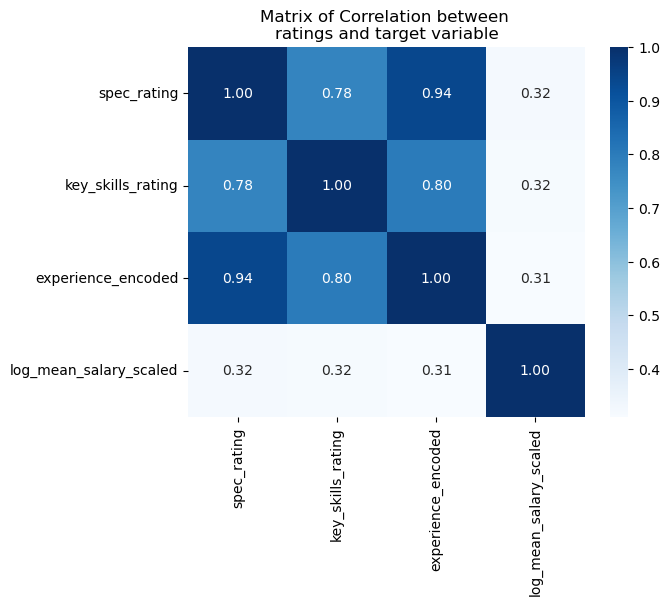

In [39]:
corr_test_df = pd.concat([X_train[['spec_rating', 'key_skills_rating', 'experience_encoded']], y_train['log_mean_salary_scaled']], axis=1)
correlation = corr_test_df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matrix of Correlation between \nratings and target variable')
plt.show()

*to be (maybe) continued…*

### **Model Initialization and Optimization**

#### CatBoost

For fitting and predicting the `CatBoostRegressor` model (from `catboost` library) is selected. It's a good regression model, especially in categorial features processing. Build-in methods of encoding-decoding and feature transformations actually are able to work better than other methods of feature preprocessing such as scalers or encoders from Scikit-learn or other libraries.

`Optuna` Framework usage for optimal selection of CatBoost Regressor hyperparameters:

In [41]:
X_train.head()

,name,region,area,employer,schedule,key_skills,experience_encoded,specs,spec_rating,key_skills_rating
0,Агент по недвижимости,Санкт-Петербург,"{'id': '2', 'name': 'Санкт-Петербург', 'url': ...","{'id': '541016', 'name': 'АРИН', 'url': 'https...","{'id': 'flexible', 'name': 'Гибкий график'}","[{'name': 'Жилая недвижимость'}, {'name': 'Акт...",0.0,"{'Строительство, недвижимость': {'Начальный ур...",5.0,3.0
1,IT-специалист/ техник,Иркутская область,"{'id': '1130', 'name': 'Братск', 'url': 'https...","{'id': '1136625', 'name': 'СМП-38', 'url': 'ht...","{'id': 'flyInFlyOut', 'name': 'Вахтовый метод'}",[],1.0,"{'Информационные технологии, интернет, телеком...",11.666667,4.5
2,Старший/ведущий инженер-программист,Ростовская область,"{'id': '76', 'name': 'Ростов-на-Дону', 'url': ...","{'id': '611346', 'name': 'САРМАТ, НПП', 'url':...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Linux'}, {'name': 'Bash'}, {'name':...",1.0,"{'Информационные технологии, интернет, телеком...",11.666667,6.5
3,Эксперт / методист приемной комиссии,Москва,"{'id': '1', 'name': 'Москва', 'url': 'https://...","{'id': '171255', 'name': 'РХТУ им. Д.И. Мендел...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': '1С программирование'}, {'name': 'Об...",1.0,"{'Маркетинг, реклама, PR': {'Менеджмент продук...",7.666667,7.833333
4,Табельщица/табельщик,Саратовская область,"{'id': '1613', 'name': 'Энгельс', 'url': 'http...","{'id': '617150', 'name': 'Сигнал, группа компа...","{'id': 'fullDay', 'name': 'Полный день'}","[{'name': 'Составление отчетности'}, {'name': ...",1.0,"{'Производство, сельское хозяйство': {'Машинос...",6.333333,9.166667


In [ ]:
cat_features = ['name', 'region', 'employer', 'schedule', 'key_skills', 'specs']

def objective(trial):
    global cat_features
    params = {
        'depth': trial.suggest_int('depth', 14, 16),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.011, 0.02),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 8, 10),
        'iterations': trial.suggest_int('iterations', 1300, 1500)
    }
    
    model = CatBoostRegressor(**params, loss_function='MAE', cat_features=cat_features, verbose=50)
    score = cross_val_score(model, X_train, y_train['log_mean_salary_scaled'], cv=3, scoring="neg_mean_absolute_error")
    
    return -score.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

In [ ]:
print(f'Best hyperparameters: {study.best_params}')

Best hyperparameters: {'depth': 14, 'learning_rate': 0.011390844560831734, 'l2_leaf_reg': 8, 'iterations': 1319}


In [ ]:
cat_features = ['name', 'region', 'employer', 'schedule', 'key_skills', 'specs']
model = CatBoostRegressor(
    # iterations=study.best_params['iterations'],
    # learning_rate=study.best_params['learning_rate'] + 0.0012,
    # depth=study.best_params['depth'],
    # l2_leaf_reg=study.best_params['l2_leaf_reg'] + 0.54,
    iterations=1350,
    learning_rate=0.03,
    depth=14,
    l2_leaf_reg=8.5,
    loss_function='MAE',
    early_stopping_rounds=20
)

In [43]:
model.fit(X_train, y_train['log_mean_salary_scaled'], cat_features=cat_features, verbose=50)

0:	learn: 0.5671159	total: 123ms	remaining: 2m 46s
50:	learn: 0.3384266	total: 2.56s	remaining: 1m 5s
100:	learn: 0.2799572	total: 5.15s	remaining: 1m 3s
150:	learn: 0.2620081	total: 7.7s	remaining: 1m 1s
200:	learn: 0.2486765	total: 10.4s	remaining: 59.7s
250:	learn: 0.2375235	total: 13.4s	remaining: 58.9s
300:	learn: 0.2281256	total: 16.3s	remaining: 56.8s
350:	learn: 0.2178015	total: 19.3s	remaining: 54.9s
400:	learn: 0.2089450	total: 22.5s	remaining: 53.3s
450:	learn: 0.1996020	total: 25.7s	remaining: 51.3s
500:	learn: 0.1919515	total: 29s	remaining: 49.1s
550:	learn: 0.1854353	total: 32.1s	remaining: 46.6s
600:	learn: 0.1793460	total: 35.4s	remaining: 44.1s
650:	learn: 0.1722314	total: 38.6s	remaining: 41.4s
700:	learn: 0.1670090	total: 41.8s	remaining: 38.7s
750:	learn: 0.1617330	total: 45s	remaining: 35.9s
800:	learn: 0.1584388	total: 48.2s	remaining: 33s
850:	learn: 0.1544716	total: 51.4s	remaining: 30.1s
900:	learn: 0.1513400	total: 54.6s	remaining: 27.2s
950:	learn: 0.1479351

           Feature Id  Importances
0               specs    17.804191
1            employer    13.445519
2              region    12.901865
3                name    11.772870
4            schedule    11.622223
5                area    10.687532
6   key_skills_rating     7.126436
7         spec_rating     6.162707
8  experience_encoded     4.700131
9          key_skills     3.776526


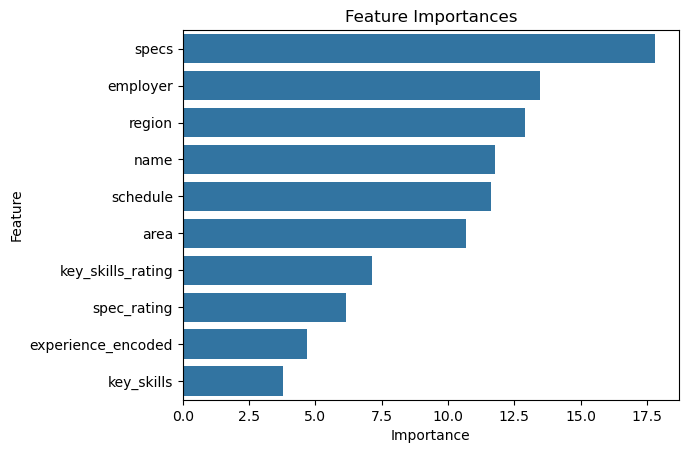

In [44]:
feature_importances = model.get_feature_importance(prettified=True)

print(feature_importances)

sns.barplot(x='Importances', y='Feature Id', data=feature_importances)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [45]:
y_hat_scaled = model.predict(X_test)
y_hat_log = scaler.inverse_transform(y_hat_scaled.reshape(-1, 1)).flatten()
y_hat = np.expm1(y_hat_log)

### **Submission Data Exporting**

In [48]:
submission_data = pd.DataFrame({'Id': range(len(y_hat)), 'Predicted': y_hat})
submission_data

,Id,Predicted
0,0,40247.542145
1,1,40314.657466
2,2,24748.565682
3,3,173546.193403
4,4,72156.171985
...,...,...
7513,7513,39191.155575
7514,7514,90913.053057
7515,7515,26773.879036
7516,7516,121192.372887


In [49]:
submission_data.to_csv("submission.csv", index=False, encoding="utf-8")